In [1]:
import pandas, numpy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/025_isafjordur/results/000_quantification/DESeq2_TPM_values.skmel.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 7)


,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4
ENSG00000000003,9.097209,9.806654,12.244351,12.179835,17.984601,12.499056,10.895395
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,152.065078,146.963798,159.427516,180.241348,197.693333,144.099788,136.583522
ENSG00000000457,4.644776,3.992320,6.102643,3.590144,5.672788,4.962348,4.242799
ENSG00000000460,20.780175,22.200583,30.912937,20.707054,26.297054,17.887952,14.196562
...,...,...,...,...,...,...,...
ENSG00000291297,5.742134,5.220425,6.054220,5.305273,2.120733,2.756115,2.122733
ENSG00000291298,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.944026
ENSG00000291299,1.784678,1.767580,1.662962,2.593021,0.870331,2.213504,1.361509
ENSG00000291300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
for element in expression.columns:
    print(element)

SkMel28-MITFKO_ev_skmel28_rep1
SkMel28-MITFKO_ev_skmel28_rep2
SkMel28-MITFKO_ev_skmel28_rep3
SkMel28-MITFKO_ev_skmel28_rep4
SkMel28-MITFKO_mitf_x6_rep1
SkMel28-MITFKO_mitf_x6_rep3
SkMel28-MITFKO_mitf_x6_rep4


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(13631, 7)
(2226, 7)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.42841303 0.2892033 ]


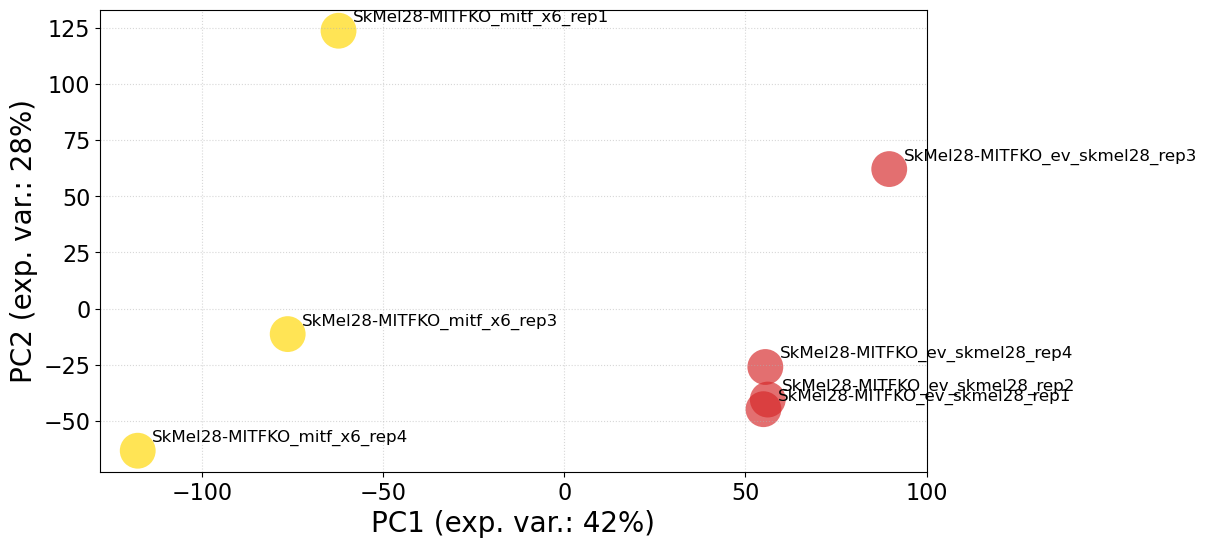

In [10]:
for i in range(len(new)):

    # colors
    if 'ev' in expression.columns[i]:
        the_color = 'tab:red'
    else:
        the_color = 'gold'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)

    if 'U2' in expression.columns[i]:
        
        if new[i, 1] > 25:
            print(expression.columns[i])
        else:
            print('\t', expression.columns[i])

#matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.5100028  0.28968122]


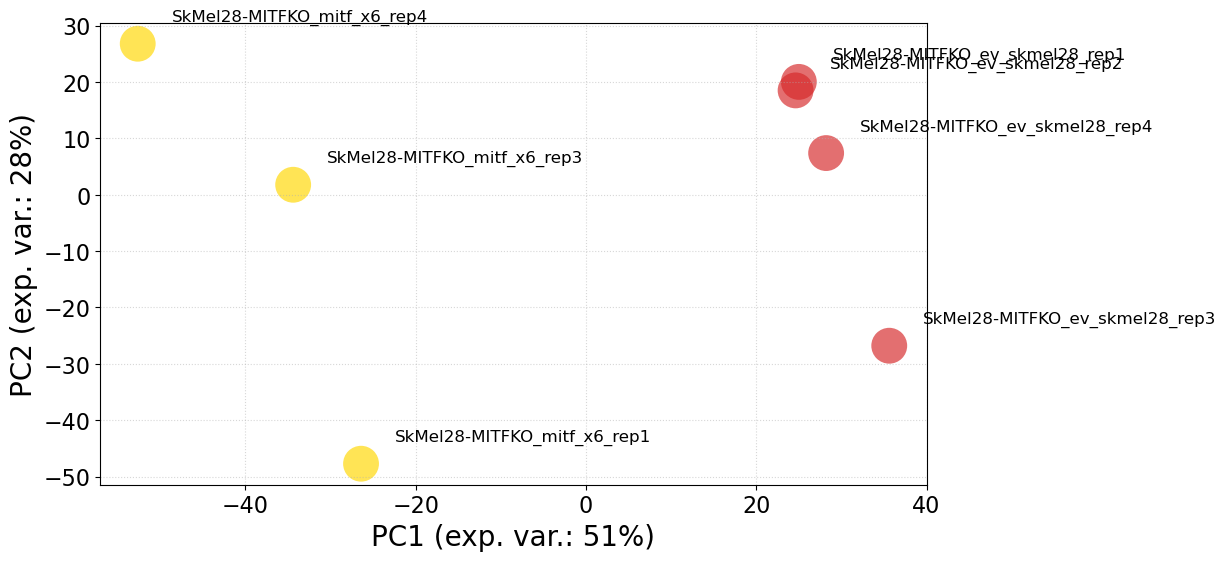

In [14]:
for i in range(len(new)):
     # colors
    if 'ev' in expression.columns[i]:
        the_color = 'tab:red'
    else:
        the_color = 'gold'    
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
        
    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.show()